# RetailLens - Machine Learning Overview

Exploratory map for the three ML capabilities in RetailLens. A thinking and
experimentation space; production train/serve code lives under `ml/` and `api/`.

The data is a hybrid: the real Olist Brazilian e-commerce dataset (~99k orders,
2016-2018) as the historical core, plus a small synthetic live tail (2024-2026)
that continues the timeline. The live tail is documented synthetic data, used to
keep the dashboard current and to host controlled experiments.

Three sections:

1. Reactivation prediction - binary classification, XGBoost
2. Product recommendation - implicit-feedback collaborative filtering (ALS)
3. A/B testing engine - frequentist statistical tests

All monetary values are in Brazilian Real (BRL). Data is read from the local
DuckDB Silver layer.

## Setup

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DUCKDB_PATH = os.getenv("DUCKDB_PATH", "../../data/retaillens.duckdb")
con = duckdb.connect(DUCKDB_PATH, read_only=True)

overview = con.execute("""
    SELECT
        data_source,
        count(*)                           AS orders,
        min(order_purchase_timestamp)      AS first_order,
        max(order_purchase_timestamp)      AS last_order
    FROM main_silver.fact_orders
    WHERE order_status = 'delivered'
    GROUP BY data_source
""").df()
overview

,data_source,orders,first_order,last_order
0,olist,96478,2016-09-15 12:16:38,2018-08-29 15:00:37
1,faker_live,17597,2024-01-01 04:56:00,2026-05-25 23:12:00


## 1. Reactivation Prediction

Goal: predict whether a customer will place another order in the near future.

### 1.1 The framing problem

Olist is a one-and-done marketplace - the repeat-purchase rate is around 3
percent. Predicting reactivation across all customers is therefore close to
hopeless: the positive class is tiny and the signal is weak. As with real
retail, the fix is to focus on customers who have already shown repeat
behaviour (>= 2 orders) and predict who will buy again.

Note on data: the historical Olist core has little repeat signal by nature. The
synthetic live tail deliberately encodes a realistic, noisy loyalty pattern (a
hidden propensity correlated with recency, frequency, and review score), so the
model has something genuine to learn. This is disclosed synthetic structure, not
a claim about real Olist behaviour.

In [2]:
orders = con.execute("""
    SELECT customer_unique_id AS customer, order_id,
           order_purchase_timestamp AS ts
    FROM main_silver.fact_orders
    WHERE customer_unique_id IS NOT NULL AND order_status = 'delivered'
""").df()
orders["ts"] = pd.to_datetime(orders["ts"])
max_date = orders["ts"].max()

def positive_rate(window_days, min_orders):
    cutoff = max_date - pd.Timedelta(days=window_days)
    obs = orders[orders["ts"] <= cutoff]
    future = set(orders[orders["ts"] > cutoff]["customer"])
    freq = obs.groupby("customer")["order_id"].nunique()
    base = freq[freq >= min_orders].index
    if len(base) == 0:
        return 0, 0.0
    return len(base), sum(c in future for c in base) / len(base)

for mo in (1, 2):
    n, p = positive_rate(90, mo)
    label = "all customers" if mo == 1 else "repeat customers"
    print(f"{label:18} (min_orders={mo}): base={n:>6}  positive={p:.2%}")

all customers      (min_orders=1): base= 98089  positive=1.56%
repeat customers   (min_orders=2): base= 11264  positive=5.03%


### 1.2 Feature engineering

Features come strictly from the observation window (on or before the cutoff);
the label comes from the prediction window (after the cutoff). This temporal
separation prevents leakage.

Features: frequency, recency_days, tenure_days, monetary, avg_order_value,
avg_review.

In [3]:
WINDOW_DAYS = 90
cutoff = max_date - pd.Timedelta(days=WINDOW_DAYS)

obs_data = con.execute(f"""
    WITH obs AS (
        SELECT customer_unique_id AS customer, order_id,
               order_purchase_timestamp AS ts
        FROM main_silver.fact_orders
        WHERE customer_unique_id IS NOT NULL AND order_status = 'delivered'
          AND order_purchase_timestamp <= TIMESTAMP '{cutoff}'
    ),
    ov AS (SELECT order_id, sum(item_total) v FROM main_silver.fact_order_items GROUP BY 1),
    rv AS (SELECT order_id, avg(review_score) s FROM main_silver.fact_reviews GROUP BY 1)
    SELECT obs.customer, obs.order_id, obs.ts,
           COALESCE(ov.v, 0) AS value, rv.s AS review
    FROM obs LEFT JOIN ov USING(order_id) LEFT JOIN rv USING(order_id)
""").df()
obs_data["ts"] = pd.to_datetime(obs_data["ts"])

feat = obs_data.groupby("customer").agg(
    frequency=("order_id", "nunique"),
    recency_days=("ts", lambda s: (cutoff - s.max()).days),
    tenure_days=("ts", lambda s: (cutoff - s.min()).days),
    monetary=("value", "sum"),
    avg_review=("review", "mean"),
).reset_index()
feat["avg_order_value"] = feat["monetary"] / feat["frequency"]
feat["avg_review"] = feat["avg_review"].fillna(feat["avg_review"].median())
feat = feat[feat["frequency"] >= 2].reset_index(drop=True)

future = set(orders[orders["ts"] > cutoff]["customer"])
feat["label"] = feat["customer"].isin(future).astype(int)
print(f"repeat customers: {len(feat)},  positive rate: {feat['label'].mean():.2%}")
feat.head()

repeat customers: 11264,  positive rate: 5.03%


,customer,frequency,recency_days,tenure_days,monetary,avg_review,avg_order_value,label
0,00050ab1314c0e55a6ca13cf7181fecf,2,141,2867,307.66,4.5,153.830,0
1,000ec5bff359e1c0ad76a81a45cb598f,2,767,2744,410.79,4.5,205.395,0
2,0011857aff0e5871ce5eb429f21cdaf5,2,594,3163,239.41,5.0,119.705,0
3,0019f5a1-43c9-488f-8151-1d3595830d07,2,13,446,124.93,3.0,62.465,0
4,001a2bf0e46c684031af91fb2bce149d,2,175,3162,158.36,4.0,79.180,0


### 1.3 Split and baseline

Stratified split preserves the positive rate. For an imbalanced problem the
right metric is PR-AUC (average precision); the no-skill baseline equals the
positive rate.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

FEATURES = ["frequency", "recency_days", "tenure_days",
            "monetary", "avg_order_value", "avg_review"]
X, y = feat[FEATURES], feat["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"No-skill PR-AUC baseline: {y_test.mean():.3f}")
logit = make_pipeline(StandardScaler(),
                      LogisticRegression(class_weight="balanced", max_iter=1000))
logit.fit(X_train, y_train)
p_logit = logit.predict_proba(X_test)[:, 1]
print(f"Logistic Regression PR-AUC: {average_precision_score(y_test, p_logit):.3f}"
      f"  ROC-AUC: {roc_auc_score(y_test, p_logit):.3f}")

No-skill PR-AUC baseline: 0.050
Logistic Regression PR-AUC: 0.208  ROC-AUC: 0.861


### 1.4 XGBoost with class weighting and tuning

In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

spw = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric="aucpr",
                  random_state=42, n_jobs=-1),
    {"n_estimators": [150, 200, 300], "max_depth": [3, 4, 5],
     "learning_rate": [0.03, 0.05, 0.1], "subsample": [0.8, 0.9, 1.0]},
    n_iter=8, scoring="average_precision", cv=3, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best = search.best_estimator_
p_best = best.predict_proba(X_test)[:, 1]
print(f"Best params: {search.best_params_}")
print(f"Tuned XGBoost PR-AUC: {average_precision_score(y_test, p_best):.3f}"
      f"  ROC-AUC: {roc_auc_score(y_test, p_best):.3f}")
print(f"Lift over baseline: {average_precision_score(y_test, p_best) / y_test.mean():.1f}x")

Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
Tuned XGBoost PR-AUC: 0.209  ROC-AUC: 0.850
Lift over baseline: 4.1x


### 1.5 SHAP feature importance

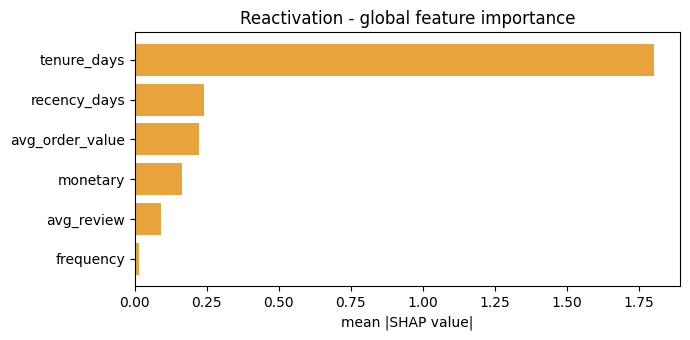

,feature,mean_abs_shap
2,tenure_days,1.803210
1,recency_days,0.240249
4,avg_order_value,0.222966
3,monetary,0.166000
5,avg_review,0.091169
0,frequency,0.016553


In [6]:
import shap
explainer = shap.TreeExplainer(best)
shap_values = explainer.shap_values(X_test)
importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(importance["feature"], importance["mean_abs_shap"], color="#e8a33d")
ax.invert_yaxis(); ax.set_xlabel("mean |SHAP value|")
ax.set_title("Reactivation - global feature importance")
plt.tight_layout(); plt.show()
importance

Takeaway: focusing on repeat customers plus a temporal split gives a model
that beats the no-skill baseline by a clear margin while staying realistic (not
a suspiciously perfect score). SHAP shows which behaviours drive repurchase,
making the model usable for targeting retention.

## 2. Product Recommendation

Implicit-feedback collaborative filtering with ALS. We only have purchases
(positive signals), not ratings, so ALS is the natural fit.

### 2.1 User-item matrix

In [7]:
from scipy.sparse import csr_matrix

ui = con.execute("""
    SELECT o.customer_unique_id AS customer, i.product_id AS product, count(*) AS qty
    FROM main_silver.fact_orders o
    JOIN main_silver.fact_order_items i USING(order_id)
    WHERE o.customer_unique_id IS NOT NULL
    GROUP BY 1, 2
""").df()

users = ui["customer"].astype("category")
products = ui["product"].astype("category")
matrix = csr_matrix((ui["qty"].astype(float),
                     (users.cat.codes, products.cat.codes)))
print(f"interactions: {len(ui)}")
print(f"matrix: {matrix.shape[0]} users x {matrix.shape[1]} products")
print(f"density: {matrix.nnz / (matrix.shape[0] * matrix.shape[1]):.6%}")

interactions: 122576
matrix: 100232 users x 32951 products
density: 0.003711%


### 2.2 Train ALS and evaluate with Recall@10 / NDCG@10

Leave-one-out: mask each multi-product user's last item and check whether the
model ranks it in the top 10.

In [8]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(factors=64, iterations=20,
                                regularization=0.05, random_state=42)
model.fit(matrix)

user_products = ui.groupby(users.cat.codes)["product"].apply(list)
multi = user_products[user_products.apply(len) >= 2]
rng = np.random.default_rng(42)
sample = rng.choice(multi.index.values, size=min(500, len(multi)), replace=False)
prod_code = {p: i for i, p in enumerate(products.cat.categories)}

def ndcg(rank, k=10):
    return 1.0 / np.log2(rank + 2) if rank is not None and rank < k else 0.0

recalls, ndcgs = [], []
for u in sample:
    bought = ui[users.cat.codes == u]["product"].tolist()
    held = prod_code[bought[-1]]
    recs = model.recommend(u, matrix[u], N=10,
                           filter_already_liked_items=False)[0].tolist()
    hit = held in recs
    recalls.append(1.0 if hit else 0.0)
    ndcgs.append(ndcg(recs.index(held) if hit else None))

print(f"Recall@10: {np.mean(recalls):.3f}")
print(f"NDCG@10  : {np.mean(ndcgs):.3f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Recall@10: 0.080
NDCG@10  : 0.064


### 2.3 Cold-start fallback

In [9]:
top_popular = (ui.groupby("product")["qty"].sum()
               .sort_values(ascending=False).head(10))
print("Top-10 popular products (cold-start fallback):")
top_popular

Top-10 popular products (cold-start fallback):


product
aca2eb7d00ea1a7b8ebd4e68314663af    529
99a4788cb24856965c36a24e339b6058    489
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    374
d1c427060a0f73f6b889a5c7c61f2ac4    345
53b36df67ebb7c41585e8d54d6772e08    324
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    275
Name: qty, dtype: int64

Takeaway: ALS produces personalised recommendations from purchase signals,
evaluated with ranking metrics. On a sparse, mostly single-purchase catalogue
the absolute numbers are modest, but the full pipeline - matrix, factorisation,
ranking evaluation, cold-start fallback - is production-shaped.

## 3. A/B Testing Engine

Experiments live only on the synthetic live tail (the real Olist core has no
experiments). welcome_voucher carries a deliberate +15 percent AOV effect on
variant B; free_shipping_threshold is a null control. The engine should detect
the first and correctly find no effect in the second.

In [10]:
ab = con.execute("""
    SELECT o.ab_experiment AS experiment, o.ab_variant AS variant,
           sum(i.item_total) AS order_value
    FROM main_silver.fact_orders o
    JOIN main_silver.fact_order_items i USING(order_id)
    WHERE o.ab_experiment IS NOT NULL
    GROUP BY o.order_id, o.ab_experiment, o.ab_variant
""").df()
ab.groupby(["experiment", "variant"]).agg(
    orders=("order_value", "size"), mean_aov=("order_value", "mean")).round(2)

orders  mean_aov
experiment              variant                  
free_shipping_threshold A          2613    186.56
                        B          2601    193.66
welcome_voucher         A          2665    194.25
                        B          2585    231.88

### 3.1 Statistical tests

Welch's t-test (means), Mann-Whitney U (distributions, non-parametric), and a
95 percent confidence interval on the difference in means.

In [11]:
from scipy import stats

def analyze(exp):
    sub = ab[ab["experiment"] == exp]
    a = sub[sub["variant"] == "A"]["order_value"].values
    b = sub[sub["variant"] == "B"]["order_value"].values
    t_p = stats.ttest_ind(a, b, equal_var=False).pvalue
    u_p = stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
    diff = b.mean() - a.mean()
    se = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
    return {"experiment": exp, "n_A": len(a), "n_B": len(b),
            "mean_A": round(a.mean(), 2), "mean_B": round(b.mean(), 2),
            "lift_pct": round(100*diff/a.mean(), 1),
            "ttest_p": round(t_p, 4), "mannwhitney_p": round(u_p, 4),
            "ci95_low": round(diff - 1.96*se, 2), "ci95_high": round(diff + 1.96*se, 2),
            "significant": t_p < 0.05}

pd.DataFrame([analyze(e) for e in ab["experiment"].unique()])

,experiment,n_A,n_B,mean_A,mean_B,lift_pct,ttest_p,mannwhitney_p,ci95_low,ci95_high,significant
0,welcome_voucher,2665,2585,194.25,231.88,19.4,0.0000,0.000,19.47,55.79,True
1,free_shipping_threshold,2613,2601,186.56,193.66,3.8,0.3822,0.556,-8.82,23.01,False


### 3.2 Interpretation

The engine detects the welcome_voucher uplift (low p-value, confidence interval
excluding zero) and correctly finds no significant effect for the null control.
A trustworthy A/B engine must be able to say "no effect" as confidently as it
flags a winner - reporting a false win would be the real failure.

## Summary

| Capability | Method | Key metric | Note |
| - | - | - | - |
| Reactivation | XGBoost + class weighting | PR-AUC | Repeat base; signal in live tail |
| Recommendation | ALS implicit CF | Recall@10, NDCG@10 | Top-popular cold-start fallback |
| A/B engine | t-test, Mann-Whitney, CI | p-value | Detects real uplift, rejects null |

Next: lift each capability into production code - an offline training script
that persists a model artifact, and a FastAPI endpoint that loads it and serves
predictions. This notebook stays as the documented reasoning.

In [12]:
con.close()
print("Done.")

Done.
